# BusterNet Validation Diagnostics

Validation-split notebook for Einar's DINO-BusterNet checkpoints. It rebuilds the same validation split, caches prediction probabilities once, reports forged/authentic diagnostics, and plots examples. Do not use the reserved local holdout split here.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "einar_busternet").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(PROJECT_ROOT)


/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle


## Configuration

`ALLOW_TORCH_HUB` must be `True` before the model is rebuilt. This is intentional because model construction uses official DINO through `torch.hub` and may initialize cached DINO assets.

In [2]:
CHECKPOINT_CHOICE = "best"  # "best", "last", or "custom"
CUSTOM_CHECKPOINT_PATH = None
CHECKPOINT_PATHS = {
    "best": Path("einar_busternet/artifacts/checkpoints/best.pt"),
    "last": Path("einar_busternet/artifacts/checkpoints/last.pt"),
}
CHECKPOINT_PATH = Path(CUSTOM_CHECKPOINT_PATH) if CHECKPOINT_CHOICE == "custom" else CHECKPOINT_PATHS[CHECKPOINT_CHOICE]

DEVICE = "auto"
ALLOW_TORCH_HUB = True
VAL_SUBSET = None
BATCH_SIZE = None
VALIDATION_TRANSFER_MODE = None  # None uses checkpoint config, usually "accumulate_gpu"
THRESHOLD_FOR_TABLES = None      # None uses config.pred_threshold unless USE_BEST_SWEEP_FOR_TABLES is True
USE_BEST_SWEEP_FOR_TABLES = True
TABLE_SWEEP_RANK = 0             # 0 is best row after sorting by kaggle_score

# Exact lightweight sweep from the best settings seen in the wider 32-setting sweep.
CUSTOM_SWEEP_SETTINGS = [
    {"pred_threshold": 0.15, "min_component_area": 10, "apply_opening": False},
    {"pred_threshold": 0.15, "min_component_area": 25, "apply_opening": False},
    {"pred_threshold": 0.15, "min_component_area": 10, "apply_opening": True},
    {"pred_threshold": 0.15, "min_component_area": 0, "apply_opening": True},
    {"pred_threshold": 0.15, "min_component_area": 50, "apply_opening": False},
]

# Fallback product sweep. Used only when CUSTOM_SWEEP_SETTINGS = None.
MAX_SWEEP_SETTINGS = 5
PRED_THRESHOLDS = [0.15, 0.2, 0.25, 0.3]
MIN_COMPONENT_AREAS = [0, 10, 25, 50]
CONFIDENT_THRESHOLDS = None
SMOOTH_OPTIONS = None
OPENING_OPTIONS = [False, True]
CLOSING_OPTIONS = None
FILL_HOLES_OPTIONS = None
KEEP_CONFIDENT_SEEDED_OPTIONS = None



In [3]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from dataset_utils import list_labeled_samples
from datasets.splits import make_grouped_stratified_splits
from engine.checkpointing import load_checkpoint
from engine.validation_inference import collect_validation_predictions, score_validation_predictions, _post_process_probability
from engine.validation_records import load_resized_instance_masks
from evaluate_validation_postprocess import iter_postprocess_settings
from einar_busternet.evaluate import (
    _build_val_loader,
    _resolve_device,
    config_from_checkpoint,
    validate_model_loading_allowed,
)
from einar_busternet.model import BusterNetUnionWrapper
from einar_busternet.train import _build_sliding_window_fn, build_model
from inference.postprocess import post_process_prediction
from util.pixelmapUtil import PixelMapUtil
from visualization import ForgeryDataPlotter


## Load Checkpoint And Validation Split

In [4]:
validate_model_loading_allowed(ALLOW_TORCH_HUB)
if CHECKPOINT_CHOICE not in {"best", "last", "custom"}:
    raise ValueError(f"CHECKPOINT_CHOICE must be 'best', 'last', or 'custom', got {CHECKPOINT_CHOICE!r}")
if CHECKPOINT_CHOICE == "custom" and CUSTOM_CHECKPOINT_PATH is None:
    raise ValueError("CUSTOM_CHECKPOINT_PATH must be set when CHECKPOINT_CHOICE='custom'")

device = _resolve_device(DEVICE)
checkpoint = load_checkpoint(CHECKPOINT_PATH, map_location=device, trusted=True)
config = config_from_checkpoint(checkpoint)
if VAL_SUBSET is not None:
    config = type(config)(**{**config.__dict__, "val_subset": VAL_SUBSET})
if BATCH_SIZE is not None:
    config = type(config)(**{**config.__dict__, "batch_size": BATCH_SIZE})
if VALIDATION_TRANSFER_MODE is not None:
    config = type(config)(**{**config.__dict__, "validation_transfer_mode": VALIDATION_TRANSFER_MODE})

all_samples = list_labeled_samples(Path(config.data_root))
splits = make_grouped_stratified_splits(
    all_samples,
    seed=config.seed,
    train_ratio=config.train_ratio,
    val_ratio=config.val_ratio,
    test_ratio=config.test_ratio,
)
val_samples = splits["val"]
if config.val_subset is not None:
    val_samples = val_samples[: config.val_subset]

print(f"device={device}")
print(f"checkpoint_choice={CHECKPOINT_CHOICE}")
print(f"checkpoint={CHECKPOINT_PATH}")
print(f"checkpoint_epoch={checkpoint.get('epoch')}")
print(f"stored_kaggle_score={checkpoint.get('kaggle_score')}")
print(f"validation samples={len(val_samples)}")
print(f"batch_size={config.val_batch_size or config.batch_size}, transfer={config.validation_transfer_mode}")


device=cuda
checkpoint_choice=best
checkpoint=einar_busternet/artifacts/checkpoints/best.pt
checkpoint_epoch=8
stored_kaggle_score=0.5315236931186152
validation samples=514
batch_size=32, transfer=accumulate_gpu


## Cache Validation Predictions

This is the expensive cell. After it runs, the rest of the notebook reuses cached probability maps.

In [5]:
model = build_model(config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
wrapped_model = BusterNetUnionWrapper(model, eps=config.union_wrapper_eps)

val_loader = _build_val_loader(config, val_samples, device)
predictions = collect_validation_predictions(
    model=wrapped_model,
    val_loader=val_loader,
    val_samples=val_samples,
    device=device,
    inference_mode=config.validation_inference_mode,
    sliding_window_fn=_build_sliding_window_fn(config),
    probability_dtype=config.validation_probability_dtype,
    collect_masks=config.compute_pixel_f1,
    transfer_mode=config.validation_transfer_mode,
)
len(predictions)


Using cache found in /home/einar/.cache/torch/hub/facebookresearch_dinov2_main


514

## Overall Score

In [6]:
pixel_util = PixelMapUtil()
score_result = score_validation_predictions(
    predictions=predictions,
    pixel_util=pixel_util,
    pred_threshold=config.pred_threshold,
    harden_temperature=config.harden_temperature,
    hard_clip_low=config.hard_clip_low,
    hard_clip_high=config.hard_clip_high,
    min_component_area=config.min_component_area,
    compute_pixel_f1=config.compute_pixel_f1,
    verify_score_equivalence=config.verify_score_equivalence,
    confident_threshold=config.post_process_confident_threshold,
    smooth_probabilities=config.post_process_smooth_probabilities,
    fill_holes=config.post_process_fill_holes,
    apply_opening=config.post_process_apply_opening,
    apply_closing=config.post_process_apply_closing,
    keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
)
score_result


{'kaggle_score': 0.5315236931186152,
 'pixel_f1': None,
 'num_samples': 514,
 'num_forged': 276,
 'num_authentic': 238,
 'postprocess_seconds': 5.161561612000696,
 'scoring_seconds': 0.08420571500028018}

## Focused Post-Processing Sweep

This reuses cached probabilities. By default it runs five exact settings chosen from the best rows of the wider threshold/component/opening sweep. Set `CUSTOM_SWEEP_SETTINGS = None` to fall back to the small product sweep.



In [7]:
def complete_sweep_setting(partial_setting):
    return {
        "pred_threshold": partial_setting.get("pred_threshold", config.pred_threshold),
        "min_component_area": partial_setting.get("min_component_area", config.min_component_area),
        "confident_threshold": partial_setting.get("confident_threshold", config.post_process_confident_threshold),
        "smooth_probabilities": partial_setting.get("smooth_probabilities", config.post_process_smooth_probabilities),
        "apply_opening": partial_setting.get("apply_opening", config.post_process_apply_opening),
        "apply_closing": partial_setting.get("apply_closing", config.post_process_apply_closing),
        "fill_holes": partial_setting.get("fill_holes", config.post_process_fill_holes),
        "keep_confident_seeded_components": partial_setting.get(
            "keep_confident_seeded_components",
            config.post_process_keep_confident_seeded_components,
        ),
        "harden_temperature": config.harden_temperature,
        "hard_clip_low": config.hard_clip_low,
        "hard_clip_high": config.hard_clip_high,
        "compute_pixel_f1": config.compute_pixel_f1,
        "verify_score_equivalence": False,
    }

if CUSTOM_SWEEP_SETTINGS is not None:
    sweep_settings = [complete_sweep_setting(setting) for setting in CUSTOM_SWEEP_SETTINGS]
else:
    sweep_args = SimpleNamespace(
        pred_thresholds=PRED_THRESHOLDS or [config.pred_threshold],
        min_component_areas=MIN_COMPONENT_AREAS or [config.min_component_area],
        confident_thresholds=CONFIDENT_THRESHOLDS or [config.post_process_confident_threshold],
        smooth_options=SMOOTH_OPTIONS or [config.post_process_smooth_probabilities],
        opening_options=OPENING_OPTIONS or [config.post_process_apply_opening],
        closing_options=CLOSING_OPTIONS or [config.post_process_apply_closing],
        fill_holes_options=FILL_HOLES_OPTIONS or [config.post_process_fill_holes],
        keep_confident_seeded_options=KEEP_CONFIDENT_SEEDED_OPTIONS or [config.post_process_keep_confident_seeded_components],
        max_settings=MAX_SWEEP_SETTINGS,
    )
    sweep_settings = iter_postprocess_settings(config, sweep_args)

sweep_rows = []
for rank, setting in enumerate(sweep_settings, start=1):
    result = score_validation_predictions(
        predictions=predictions,
        pixel_util=pixel_util,
        pred_threshold=setting["pred_threshold"],
        harden_temperature=setting["harden_temperature"],
        hard_clip_low=setting["hard_clip_low"],
        hard_clip_high=setting["hard_clip_high"],
        min_component_area=setting["min_component_area"],
        compute_pixel_f1=setting["compute_pixel_f1"],
        verify_score_equivalence=setting["verify_score_equivalence"],
        confident_threshold=setting["confident_threshold"],
        smooth_probabilities=setting["smooth_probabilities"],
        fill_holes=setting["fill_holes"],
        apply_opening=setting["apply_opening"],
        apply_closing=setting["apply_closing"],
        keep_confident_seeded_components=setting["keep_confident_seeded_components"],
    )
    sweep_rows.append({"rank": rank, **setting, **result})

sweep_df = pd.DataFrame(sweep_rows).sort_values("kaggle_score", ascending=False).reset_index(drop=True)
TABLE_POSTPROCESS_SETTING = None
if USE_BEST_SWEEP_FOR_TABLES and len(sweep_df):
    TABLE_POSTPROCESS_SETTING = sweep_df.iloc[TABLE_SWEEP_RANK].to_dict()
    print(
        "Using sweep setting for diagnostic tables:",
        {
            "pred_threshold": TABLE_POSTPROCESS_SETTING["pred_threshold"],
            "min_component_area": TABLE_POSTPROCESS_SETTING["min_component_area"],
            "apply_opening": TABLE_POSTPROCESS_SETTING["apply_opening"],
            "kaggle_score": TABLE_POSTPROCESS_SETTING["kaggle_score"],
        },
    )
sweep_df



Using sweep setting for diagnostic tables: {'pred_threshold': 0.15, 'min_component_area': 10, 'apply_opening': False, 'kaggle_score': 0.5326715982033028}


,rank,pred_threshold,min_component_area,confident_threshold,smooth_probabilities,apply_opening,apply_closing,fill_holes,keep_confident_seeded_components,harden_temperature,...,hard_clip_high,compute_pixel_f1,verify_score_equivalence,kaggle_score,pixel_f1,num_samples,num_forged,num_authentic,postprocess_seconds,scoring_seconds
0,3,0.15,10,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.532672,None,514,276,238,4.931478,0.085863
1,5,0.15,25,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.532672,None,514,276,238,5.025644,0.097740
2,4,0.15,10,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.532640,None,514,276,238,5.817550,0.088681
3,2,0.15,0,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.532640,None,514,276,238,5.367089,0.084976
4,6,0.15,25,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.532640,None,514,276,238,5.795175,0.095773
5,7,0.15,50,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.532535,None,514,276,238,4.983998,0.081562
6,8,0.15,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.532521,None,514,276,238,5.757094,0.081853
7,23,0.25,50,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.532090,None,514,276,238,4.929880,0.085834
8,24,0.25,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.532068,None,514,276,238,5.661405,0.080084
9,1,0.15,0,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.532066,None,514,276,238,4.642709,0.086113


## Per-Sample Diagnostics

Authentic rows expose false positives. Forged rows expose empty predictions, missed GT area, predicted area ratio, and pixel IoU/F1 for quick debugging.

In [8]:
def gt_union_for_prediction(prediction):
    shape = prediction.probability.shape
    instances = load_resized_instance_masks(prediction.sample, shape)
    if not instances:
        return np.zeros(shape, dtype=np.uint8)
    gt = np.zeros(shape, dtype=np.uint8)
    for instance in instances:
        gt = np.maximum(gt, (instance > 0).astype(np.uint8))
    return gt


def pred_mask_for_prediction(prediction, threshold=None, setting=None):
    setting = setting or {}
    threshold = setting.get("pred_threshold", config.pred_threshold if threshold is None else threshold)
    return _post_process_probability(
        probability=prediction.probability,
        pixel_util=pixel_util,
        pred_threshold=threshold,
        harden_temperature=setting.get("harden_temperature", config.harden_temperature),
        hard_clip_low=setting.get("hard_clip_low", config.hard_clip_low),
        hard_clip_high=setting.get("hard_clip_high", config.hard_clip_high),
        min_component_area=setting.get("min_component_area", config.min_component_area),
        confident_threshold=setting.get("confident_threshold", config.post_process_confident_threshold),
        smooth_probabilities=setting.get("smooth_probabilities", config.post_process_smooth_probabilities),
        fill_holes=setting.get("fill_holes", config.post_process_fill_holes),
        apply_opening=setting.get("apply_opening", config.post_process_apply_opening),
        apply_closing=setting.get("apply_closing", config.post_process_apply_closing),
        keep_confident_seeded_components=setting.get(
            "keep_confident_seeded_components",
            config.post_process_keep_confident_seeded_components,
        ),
    )


def pixel_stats(pred_bin, gt_bin):
    pred = pred_bin > 0
    gt = gt_bin > 0
    tp = int((pred & gt).sum())
    fp = int((pred & ~gt).sum())
    fn = int((~pred & gt).sum())
    union = tp + fp + fn
    precision = tp / (tp + fp) if tp + fp else 1.0 if gt.sum() == 0 else 0.0
    recall = tp / (tp + fn) if tp + fn else 1.0 if pred.sum() == 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0
    iou = tp / union if union else 1.0
    return tp, fp, fn, precision, recall, f1, iou


def gt_size_bucket(gt_pixels):
    if gt_pixels == 0:
        return "authentic"
    if gt_pixels < 1_000:
        return "tiny"
    if gt_pixels < 5_000:
        return "small"
    if gt_pixels < 20_000:
        return "medium"
    return "large"

rows = []
table_setting = globals().get("TABLE_POSTPROCESS_SETTING")
threshold = config.pred_threshold if THRESHOLD_FOR_TABLES is None else THRESHOLD_FOR_TABLES
if table_setting is not None and THRESHOLD_FOR_TABLES is None:
    threshold = table_setting["pred_threshold"]
print(
    "Diagnostic table postprocess:",
    {
        "pred_threshold": threshold,
        "min_component_area": table_setting.get("min_component_area", config.min_component_area) if table_setting else config.min_component_area,
        "apply_opening": table_setting.get("apply_opening", config.post_process_apply_opening) if table_setting else config.post_process_apply_opening,
    },
)
for idx, prediction in enumerate(predictions):
    pred_bin = pred_mask_for_prediction(prediction, threshold=threshold, setting=table_setting)
    gt_bin = gt_union_for_prediction(prediction)
    probability = prediction.probability.astype(np.float32, copy=False)
    tp, fp, fn, precision, recall, f1, iou = pixel_stats(pred_bin, gt_bin)
    gt_pixels = int(gt_bin.sum())
    pred_pixels = int(pred_bin.sum())
    rows.append({
        "idx": idx,
        "sample_id": prediction.sample.sample_id,
        "case_id": prediction.sample.case_id,
        "label": prediction.sample.label,
        "gt_pixels": gt_pixels,
        "pred_pixels": pred_pixels,
        "pred_to_gt_ratio": pred_pixels / gt_pixels if gt_pixels else np.nan,
        "gt_size_bucket": gt_size_bucket(gt_pixels),
        "fp_pixels": fp,
        "fn_pixels": fn,
        "precision": precision,
        "recall": recall,
        "pixel_f1": f1,
        "pixel_iou": iou,
        "max_prob": float(probability.max()),
        "mean_prob": float(probability.mean()),
        "p99_prob": float(np.quantile(probability, 0.99)),
        "pred_empty": int(pred_pixels == 0),
        "gt_empty": int(gt_pixels == 0),
    })

diagnostic_df = pd.DataFrame(rows)
diagnostic_df.to_csv(config.results_dir + "/validation_diagnostics.csv", index=False)
diagnostic_df.head()



Diagnostic table postprocess: {'pred_threshold': 0.15, 'min_component_area': 10, 'apply_opening': False}


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
0,0,authentic:10030,10030,authentic,0,0,NaN,authentic,0,0,1.000000,1.000000,1.000000,1.000000,4.472733e-04,8.542544e-06,1.544952e-04,1,1
1,1,forged:10030,10030,forged,13868,20274,1.461927,medium,10599,4193,0.477212,0.697649,0.566751,0.395431,1.000000e+00,7.899632e-02,1.000000e+00,0,0
2,2,authentic:10277,10277,authentic,0,0,NaN,authentic,0,0,1.000000,1.000000,1.000000,1.000000,5.364418e-07,3.709253e-08,3.576279e-07,1,1
3,3,forged:10277,10277,forged,19782,12497,0.631736,medium,2652,9937,0.787789,0.497675,0.609994,0.438843,1.000000e+00,4.670494e-02,9.931641e-01,0,0
4,4,authentic:10730,10730,authentic,0,0,NaN,authentic,0,0,1.000000,1.000000,1.000000,1.000000,2.384186e-07,9.138306e-09,1.192093e-07,1,1


In [9]:
summary = diagnostic_df.groupby("label").agg(
    samples=("sample_id", "count"),
    mean_pred_pixels=("pred_pixels", "mean"),
    median_pred_pixels=("pred_pixels", "median"),
    total_fp_pixels=("fp_pixels", "sum"),
    empty_prediction_rate=("pred_empty", "mean"),
    nonempty_prediction_rate=("pred_empty", lambda s: 1.0 - s.mean()),
    mean_precision=("precision", "mean"),
    mean_recall=("recall", "mean"),
    mean_pixel_f1=("pixel_f1", "mean"),
    mean_pixel_iou=("pixel_iou", "mean"),
    mean_max_prob=("max_prob", "mean"),
    mean_p99_prob=("p99_prob", "mean"),
).reset_index()

forged_nonempty = diagnostic_df.query("label == 'forged' and pred_empty == 0")
forged_nonempty_summary = pd.DataFrame([{
    "samples": len(forged_nonempty),
    "mean_precision": forged_nonempty["precision"].mean(),
    "mean_recall": forged_nonempty["recall"].mean(),
    "mean_pixel_f1": forged_nonempty["pixel_f1"].mean(),
    "mean_pred_to_gt_ratio": forged_nonempty["pred_to_gt_ratio"].mean(),
}])

size_bucket_summary = diagnostic_df.query("label == 'forged'").groupby("gt_size_bucket").agg(
    samples=("sample_id", "count"),
    empty_prediction_rate=("pred_empty", "mean"),
    mean_gt_pixels=("gt_pixels", "mean"),
    mean_pred_pixels=("pred_pixels", "mean"),
    mean_precision=("precision", "mean"),
    mean_recall=("recall", "mean"),
    mean_pixel_f1=("pixel_f1", "mean"),
    mean_max_prob=("max_prob", "mean"),
).reset_index()

display(summary)
display(forged_nonempty_summary)
display(size_bucket_summary)


,label,samples,mean_pred_pixels,median_pred_pixels,total_fp_pixels,empty_prediction_rate,nonempty_prediction_rate,mean_precision,mean_recall,mean_pixel_f1,mean_pixel_iou,mean_max_prob,mean_p99_prob
0,authentic,238,997.777311,0.0,237471,0.907563,0.092437,0.907563,0.907563,0.907563,0.907563,0.083713,0.053428
1,forged,276,6313.739130,766.0,506438,0.438406,0.561594,0.388825,0.237701,0.272578,0.191996,0.545666,0.367482


,samples,mean_precision,mean_recall,mean_pixel_f1,mean_pred_to_gt_ratio
0,155,0.69236,0.423261,0.485364,0.750066


,gt_size_bucket,samples,empty_prediction_rate,mean_gt_pixels,mean_pred_pixels,mean_precision,mean_recall,mean_pixel_f1,mean_max_prob
0,large,56,0.035714,34062.625000,20517.553571,0.750498,0.450776,0.524209,0.937417
1,medium,85,0.317647,11339.435294,6107.717647,0.482929,0.298059,0.339210,0.663212
2,small,90,0.588889,2280.444444,785.077778,0.252214,0.145091,0.170296,0.399539
3,tiny,45,0.866667,555.377778,84.355556,0.034214,0.043751,0.038138,0.128378


In [10]:
authentic_fp = diagnostic_df.query("label == 'authentic'").sort_values(["pred_pixels", "max_prob"], ascending=False)
forged_misses = diagnostic_df.query("label == 'forged'").sort_values(["pixel_f1", "recall", "pred_pixels"], ascending=[True, True, True])
forged_empty_near_threshold = diagnostic_df.query("label == 'forged' and pred_empty == 1").sort_values("max_prob", ascending=False)
forged_big_fp = diagnostic_df.query("label == 'forged'").sort_values("fp_pixels", ascending=False)

print("Worst authentic false positives")
display(authentic_fp.head(10))
print("Worst forged misses")
display(forged_misses.head(10))
print("Empty forged samples closest to threshold")
display(forged_empty_near_threshold.head(10))
print("Forged with most FP pixels")
display(forged_big_fp.head(10))


Worst authentic false positives


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
503,503,authentic:7759,7759,authentic,0,42517,NaN,authentic,42517,0,0.0,0.0,0.0,0.0,0.993652,0.149195,0.973633,0,1
252,252,authentic:37980,37980,authentic,0,28411,NaN,authentic,28411,0,0.0,0.0,0.0,0.0,0.952148,0.103598,0.895020,0,1
143,143,authentic:24980,24980,authentic,0,26425,NaN,authentic,26425,0,0.0,0.0,0.0,0.0,0.987305,0.098763,0.946777,0,1
369,369,authentic:5175,5175,authentic,0,22008,NaN,authentic,22008,0,0.0,0.0,0.0,0.0,0.996094,0.084607,0.968750,0,1
321,321,authentic:4592,4592,authentic,0,19060,NaN,authentic,19060,0,0.0,0.0,0.0,0.0,0.970215,0.056093,0.681641,0,1
371,371,authentic:51924,51924,authentic,0,18117,NaN,authentic,18117,0,0.0,0.0,0.0,0.0,0.997559,0.064384,0.937988,0,1
343,343,authentic:48880,48880,authentic,0,15533,NaN,authentic,15533,0,0.0,0.0,0.0,0.0,0.938477,0.049638,0.809082,0,1
339,339,authentic:48293,48293,authentic,0,10587,NaN,authentic,10587,0,0.0,0.0,0.0,0.0,0.705566,0.027055,0.458977,0,1
511,511,authentic:8783,8783,authentic,0,10119,NaN,authentic,10119,0,0.0,0.0,0.0,0.0,0.999512,0.037621,0.940430,0,1
479,479,authentic:6419,6419,authentic,0,8025,NaN,authentic,8025,0,0.0,0.0,0.0,0.0,0.957031,0.028608,0.863281,0,1


Worst forged misses


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
11,11,forged:11010,11010,forged,479,0,0.0,tiny,0,479,0.0,0.0,0.0,0.0,4.768372e-07,4.132744e-09,5.960464e-08,1,0
17,17,forged:11747,11747,forged,813,0,0.0,tiny,0,813,0.0,0.0,0.0,0.0,6.139278e-06,6.783628e-08,9.536743e-07,1,0
21,21,forged:11954,11954,forged,1074,0,0.0,small,0,1074,0.0,0.0,0.0,0.0,2.980232e-07,5.572790e-09,1.192093e-07,1,0
23,23,forged:12046,12046,forged,552,0,0.0,tiny,0,552,0.0,0.0,0.0,0.0,1.788139e-07,2.129628e-09,5.960464e-08,1,0
29,29,forged:13254,13254,forged,2068,0,0.0,small,0,2068,0.0,0.0,0.0,0.0,1.788139e-07,3.211222e-09,1.192093e-07,1,0
33,33,forged:13986,13986,forged,113,0,0.0,tiny,0,113,0.0,0.0,0.0,0.0,1.072884e-06,7.253981e-09,1.192093e-07,1,0
34,34,forged:14111,14111,forged,626,0,0.0,tiny,0,626,0.0,0.0,0.0,0.0,2.920628e-06,1.877108e-08,4.768372e-07,1,0
35,35,forged:14153,14153,forged,357,0,0.0,tiny,0,357,0.0,0.0,0.0,0.0,4.768372e-07,5.377378e-09,1.192093e-07,1,0
43,43,forged:14868,14868,forged,1298,0,0.0,small,0,1298,0.0,0.0,0.0,0.0,4.432201e-04,1.719372e-06,2.747588e-05,1,0
49,49,forged:15176,15176,forged,10584,0,0.0,medium,0,10584,0.0,0.0,0.0,0.0,4.726648e-05,1.042296e-06,2.437644e-05,1,0


Empty forged samples closest to threshold


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
510,510,forged:8517,8517,forged,722,0,0.0,tiny,0,722,0.0,0.0,0.0,0.0,0.151978,1.243764e-04,1.734495e-05,1,0
478,478,forged:63834,63834,forged,8949,0,0.0,medium,0,8949,0.0,0.0,0.0,0.0,0.048798,4.104264e-05,1.118761e-04,1,0
492,492,forged:65039,65039,forged,10563,0,0.0,medium,0,10563,0.0,0.0,0.0,0.0,0.031006,1.296112e-04,2.498507e-03,1,0
170,170,forged:27889,27889,forged,1004,0,0.0,small,0,1004,0.0,0.0,0.0,0.0,0.000632,5.167938e-07,3.516674e-06,1,0
472,472,forged:63654,63654,forged,1533,0,0.0,small,0,1533,0.0,0.0,0.0,0.0,0.000546,3.814523e-07,2.980232e-07,1,0
43,43,forged:14868,14868,forged,1298,0,0.0,small,0,1298,0.0,0.0,0.0,0.0,0.000443,1.719372e-06,2.747588e-05,1,0
74,74,forged:17280,17280,forged,13166,0,0.0,medium,0,13166,0.0,0.0,0.0,0.0,0.000190,2.284747e-06,4.523993e-05,1,0
443,443,forged:58955,58955,forged,3995,0,0.0,small,0,3995,0.0,0.0,0.0,0.0,0.000056,4.672531e-08,2.980232e-07,1,0
49,49,forged:15176,15176,forged,10584,0,0.0,medium,0,10584,0.0,0.0,0.0,0.0,0.000047,1.042296e-06,2.437644e-05,1,0
123,123,forged:22864,22864,forged,17514,0,0.0,medium,0,17514,0.0,0.0,0.0,0.0,0.000011,1.629681e-07,2.622604e-06,1,0


Forged with most FP pixels


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
138,138,forged:24600,24600,forged,25134,67731,2.694796,large,47605,5008,0.297146,0.800748,0.433446,0.276688,1.000000,0.246370,0.985352,0,0
504,504,forged:7759,7759,forged,42211,60775,1.439791,large,24461,5897,0.597515,0.860297,0.705222,0.544666,0.975098,0.207927,0.935547,0,0
144,144,forged:24980,24980,forged,19493,42485,2.179500,medium,24459,1467,0.424291,0.924742,0.581690,0.410129,0.998535,0.169073,0.983398,0,0
322,322,forged:4592,4592,forged,18843,29286,1.554211,medium,21307,10864,0.272451,0.423446,0.331567,0.198730,0.974121,0.088204,0.828110,0,0
372,372,forged:51924,51924,forged,14739,26881,1.823801,medium,16998,4856,0.367657,0.670534,0.474916,0.311403,0.997070,0.096527,0.962891,0,0
15,15,forged:11299,11299,forged,17708,32836,1.854303,medium,16551,1423,0.495950,0.919641,0.644389,0.475350,0.998535,0.123809,0.985352,0,0
344,344,forged:48880,48880,forged,1301,16188,12.442736,small,15882,995,0.018903,0.235204,0.034993,0.017808,0.972168,0.051247,0.824219,0,0
370,370,forged:5175,5175,forged,14541,26898,1.849804,medium,15263,2906,0.432560,0.800151,0.561548,0.390384,0.998535,0.110102,0.990723,0,0
5,5,forged:10730,10730,forged,22933,24388,1.063446,large,11997,10542,0.508078,0.540313,0.523700,0.354738,1.000000,0.099172,1.000000,0,0
340,340,forged:48293,48293,forged,40208,29022,0.721797,large,11137,22323,0.616257,0.444812,0.516684,0.348330,0.937988,0.089128,0.833008,0,0


## Probability Distributions

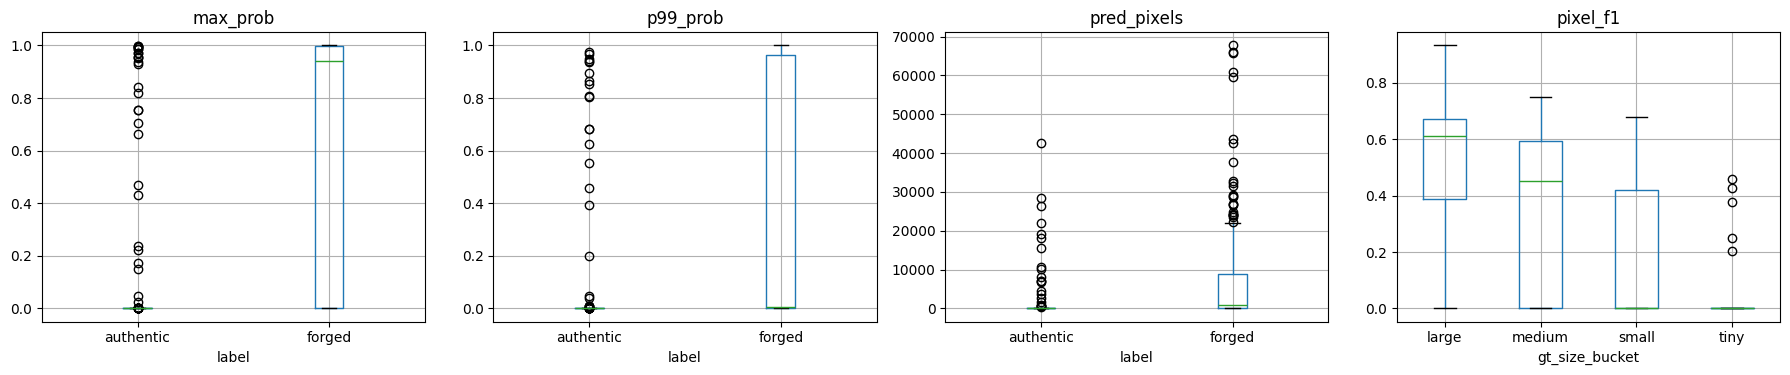

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
diagnostic_df.boxplot(column="max_prob", by="label", ax=axes[0])
diagnostic_df.boxplot(column="p99_prob", by="label", ax=axes[1])
diagnostic_df.boxplot(column="pred_pixels", by="label", ax=axes[2])
diagnostic_df.query("label == 'forged'").boxplot(column="pixel_f1", by="gt_size_bucket", ax=axes[3])
for ax in axes:
    ax.set_title(ax.get_title().replace(" by label", ""))
fig.suptitle("")
fig.tight_layout()


## Plot Examples

Authentic false positives


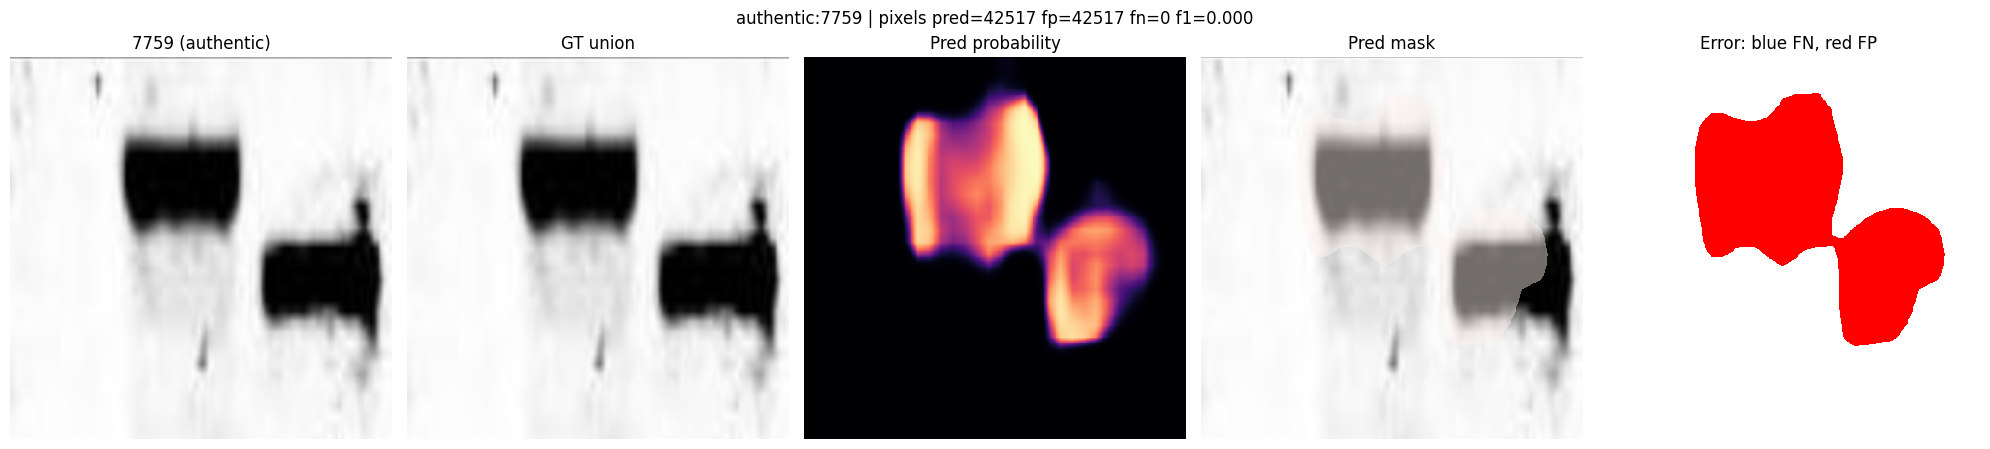

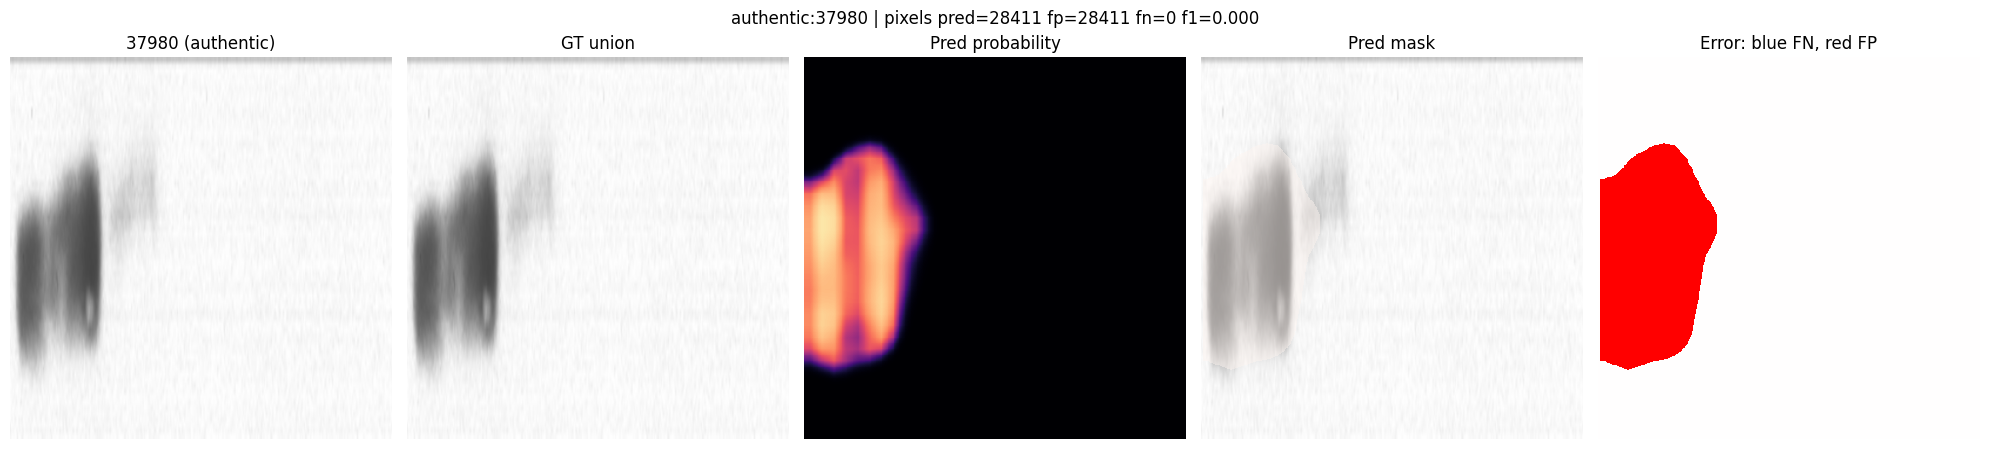

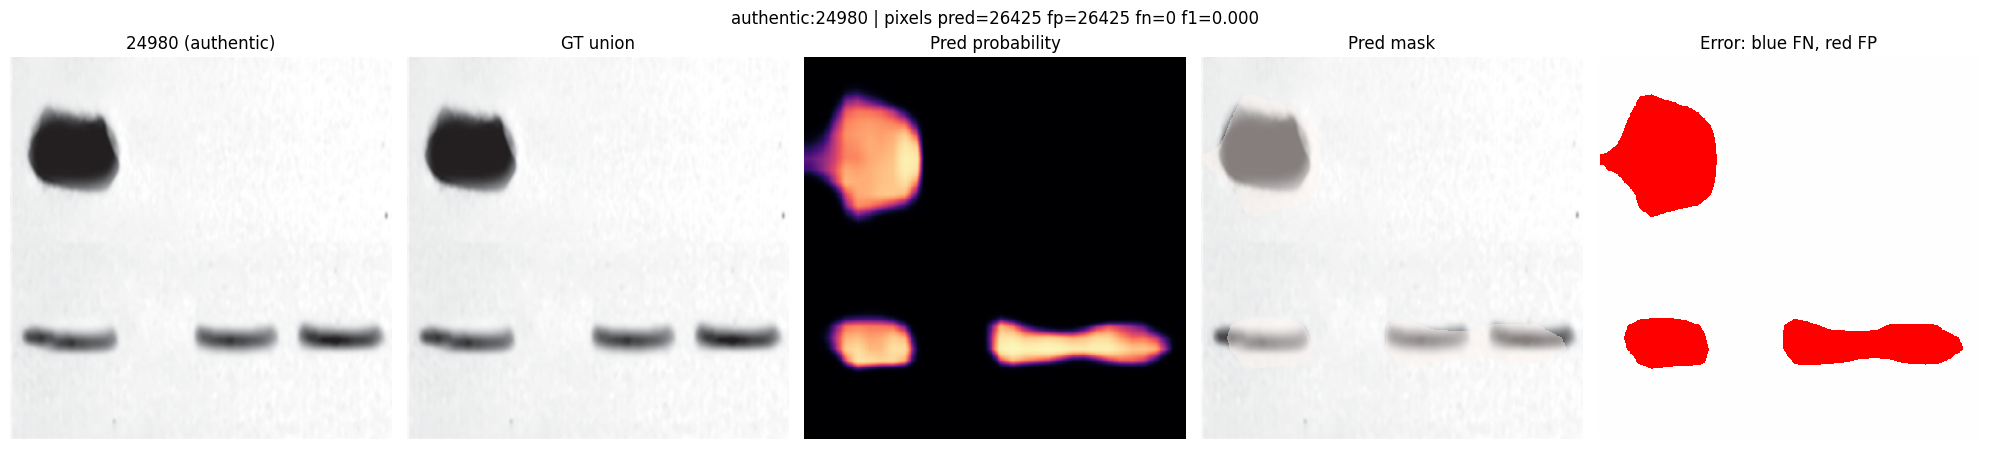

Forged misses


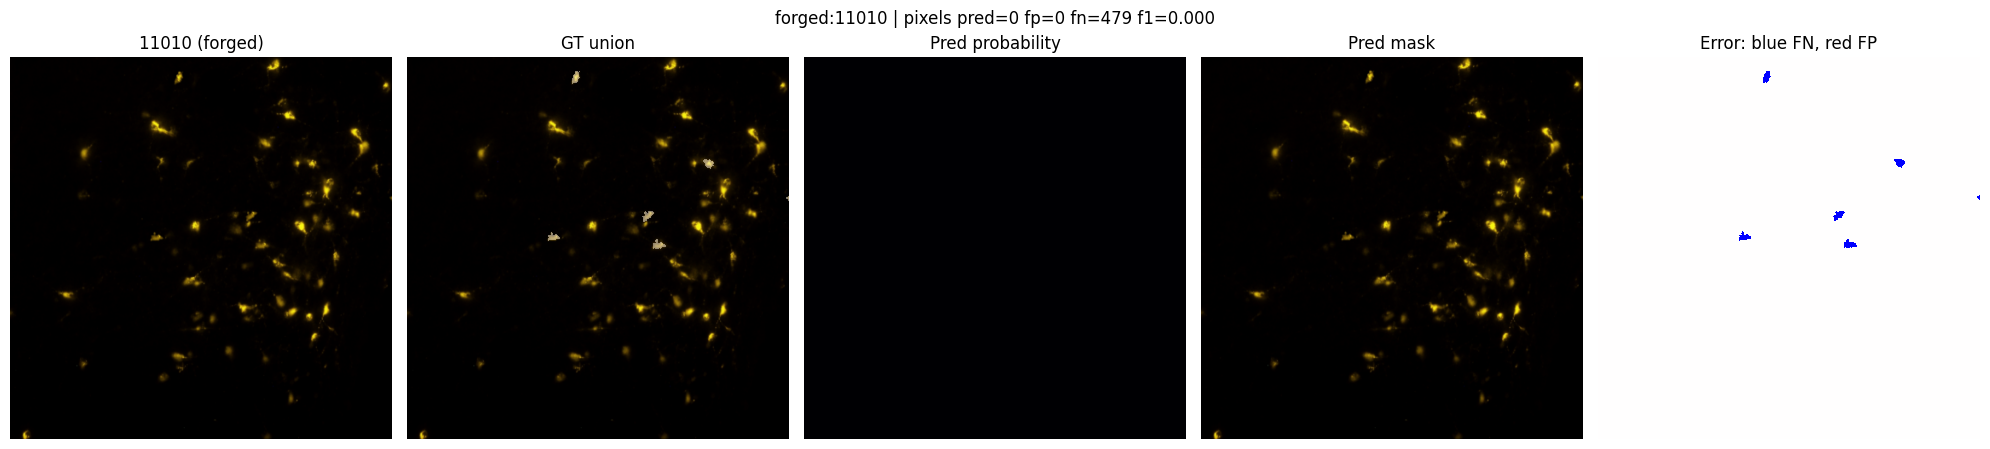

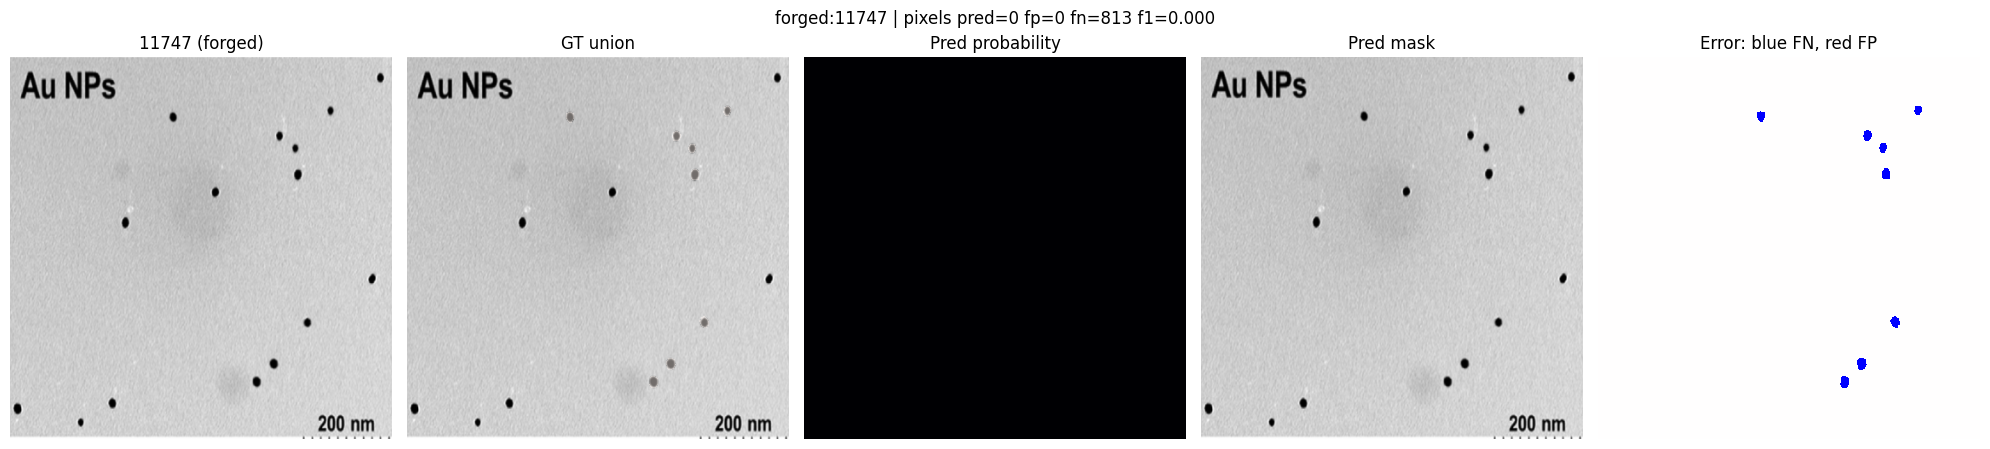

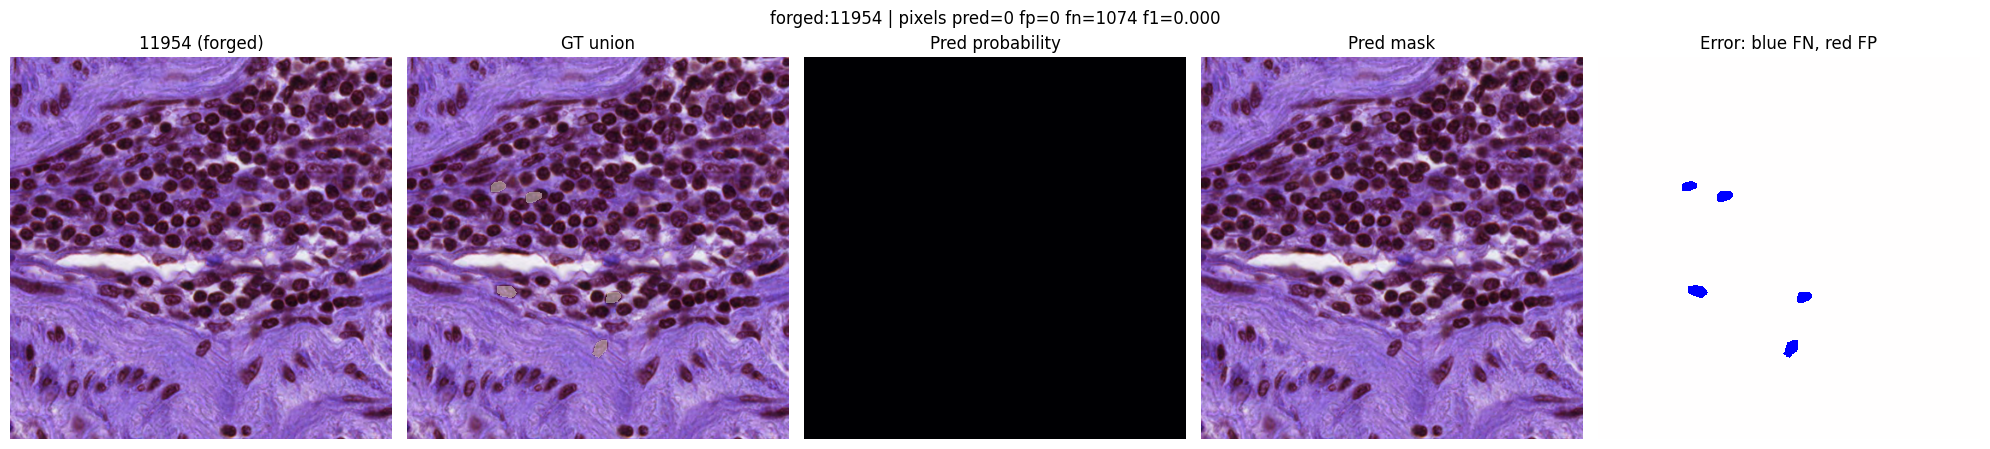

Forged successes


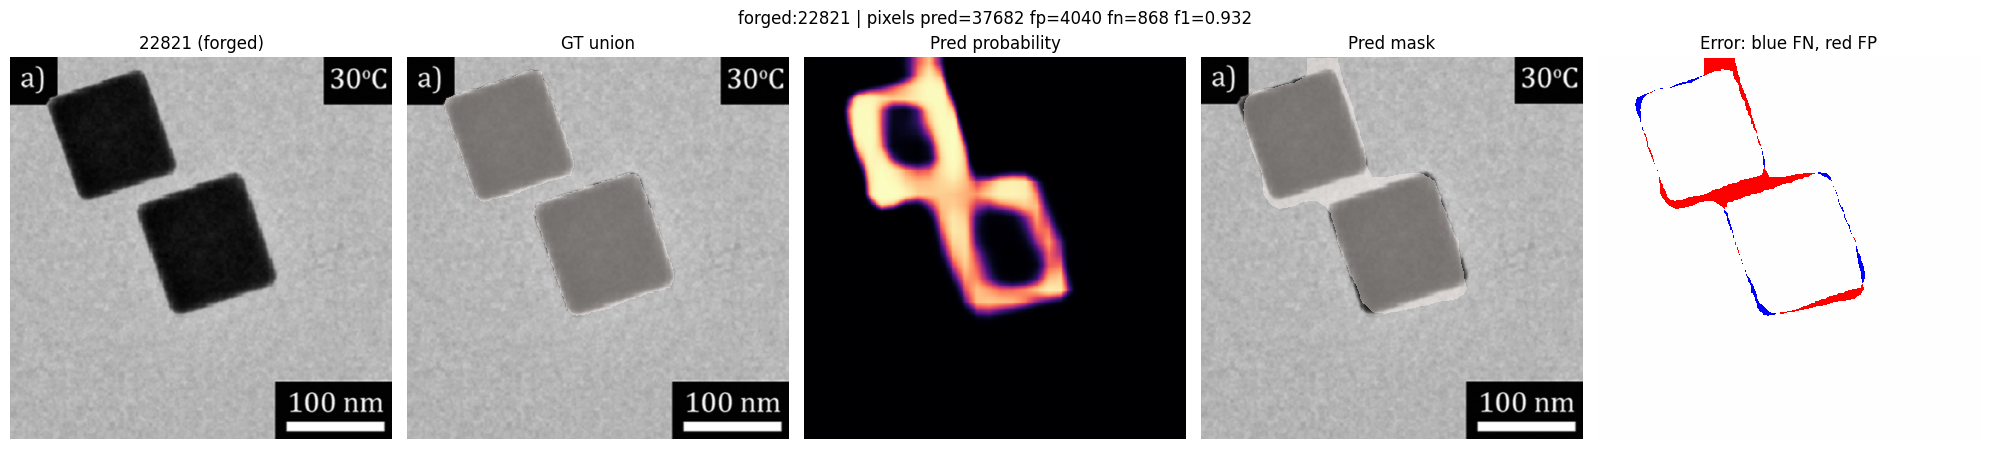

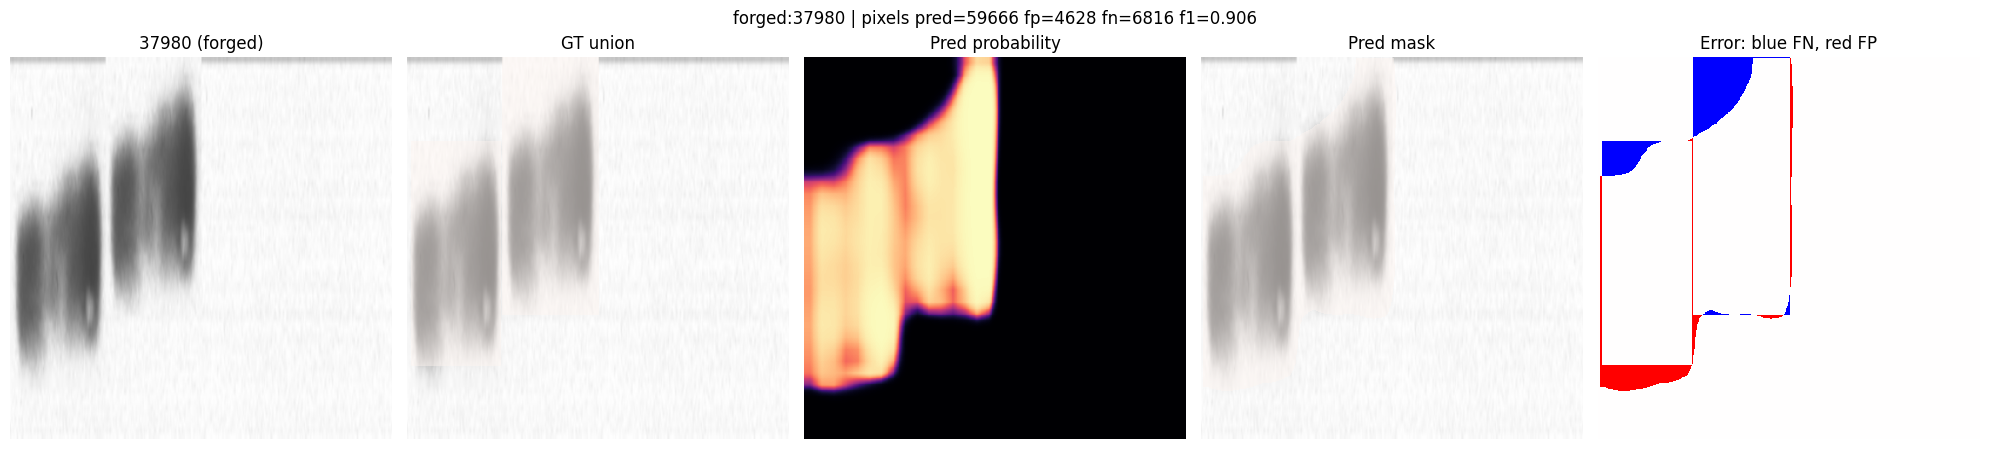

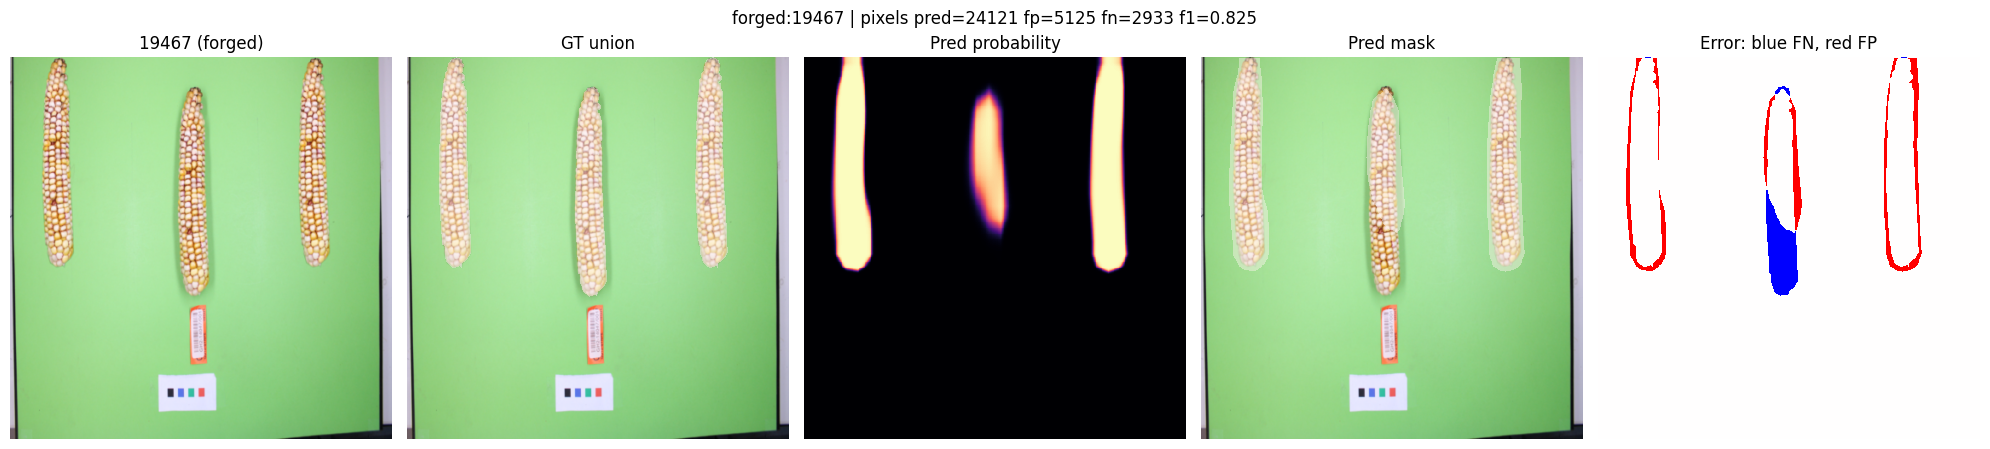

Authentic clean examples


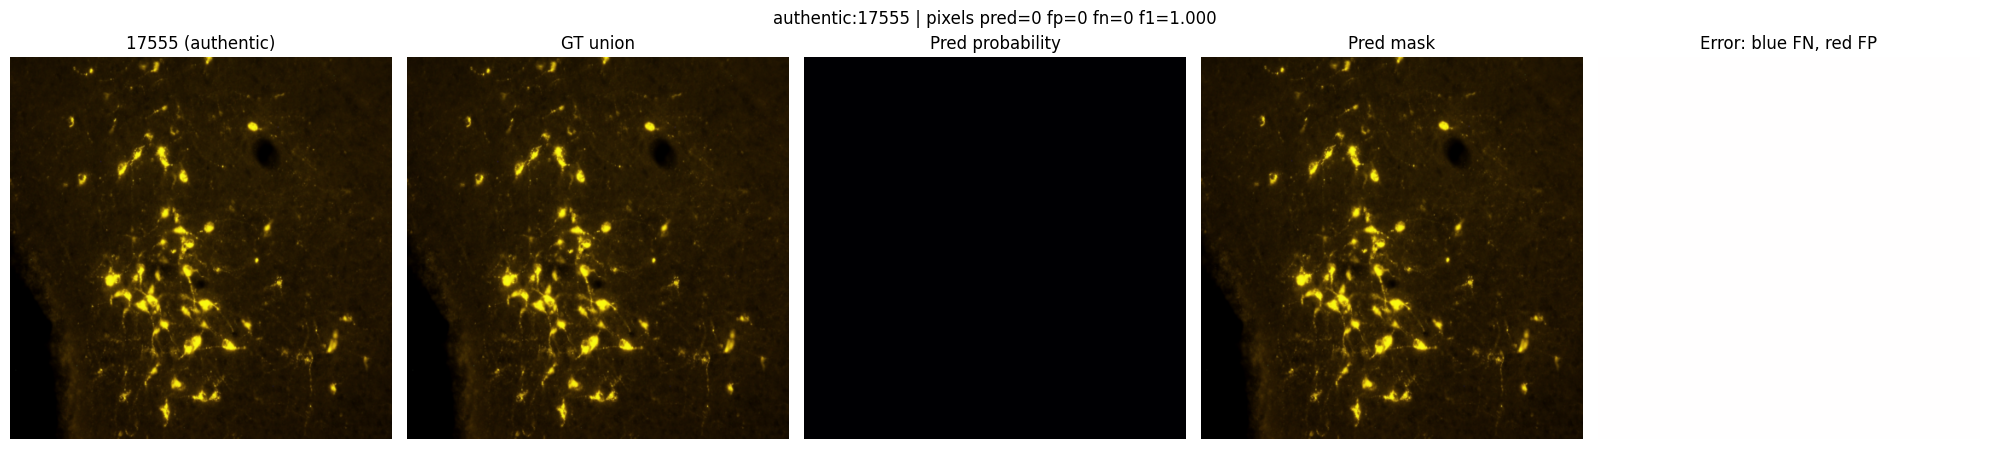

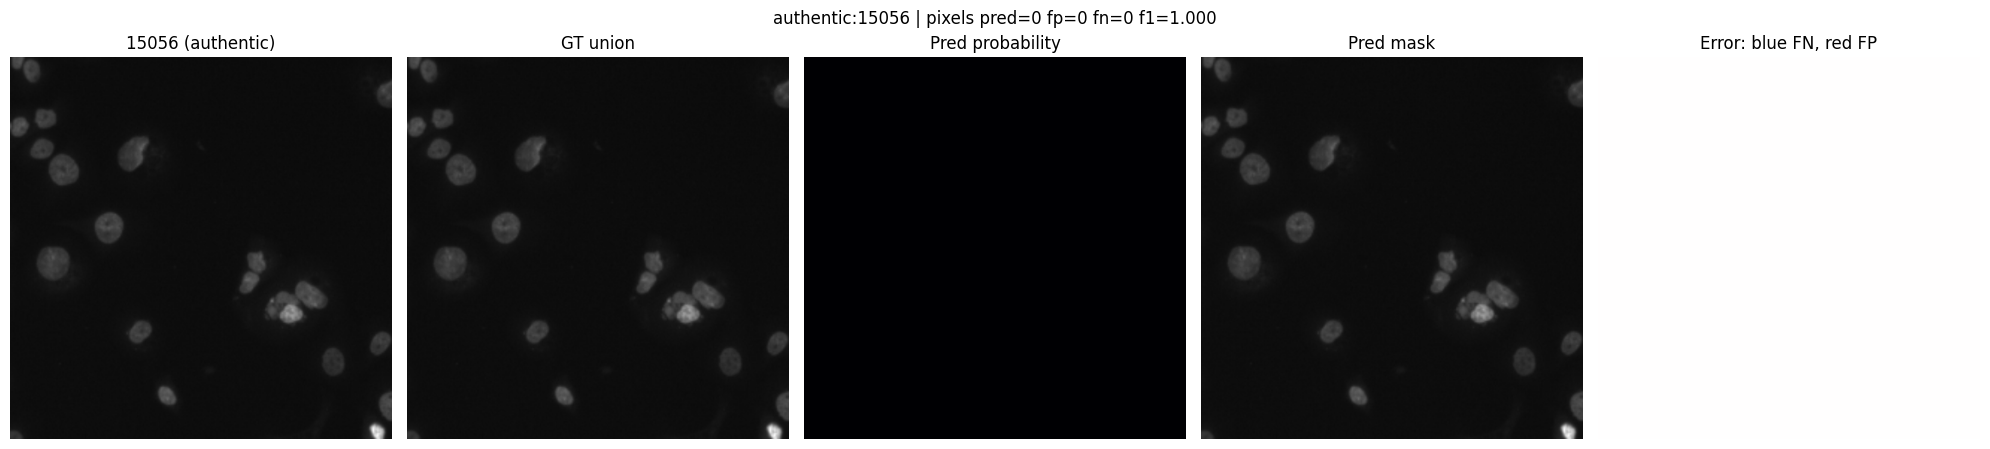

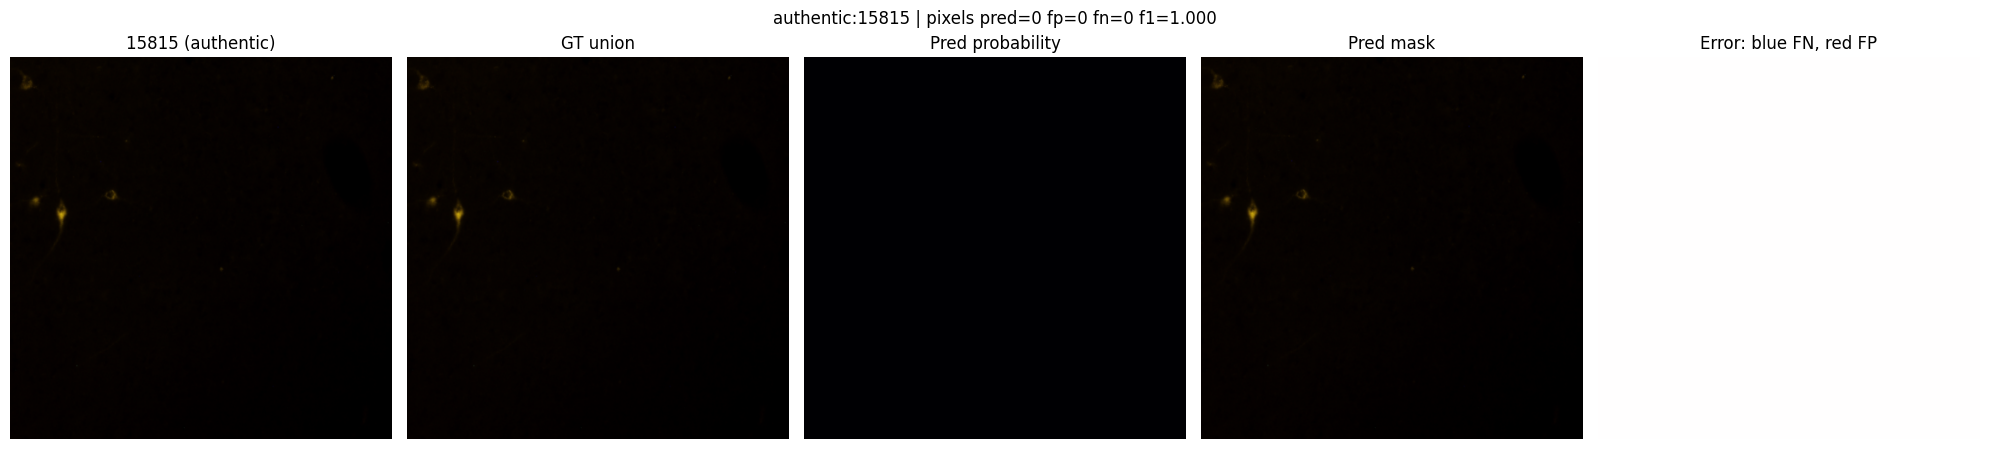

Random validation examples


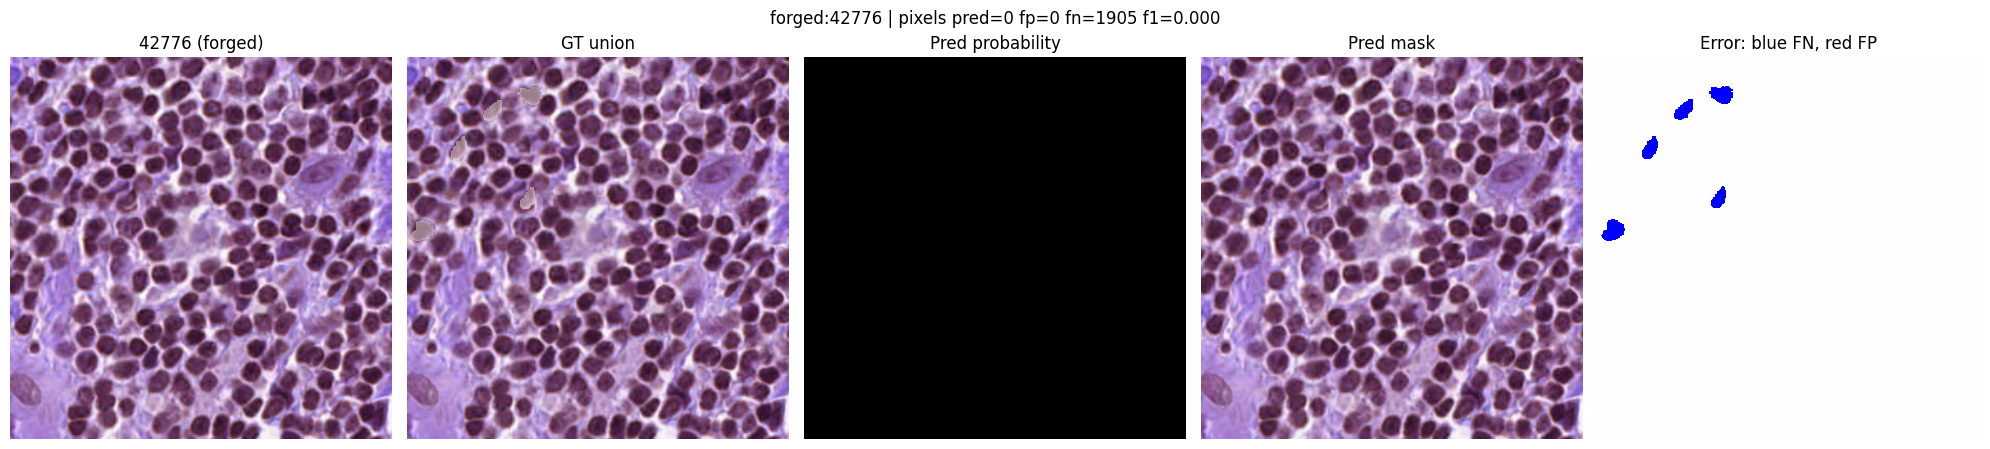

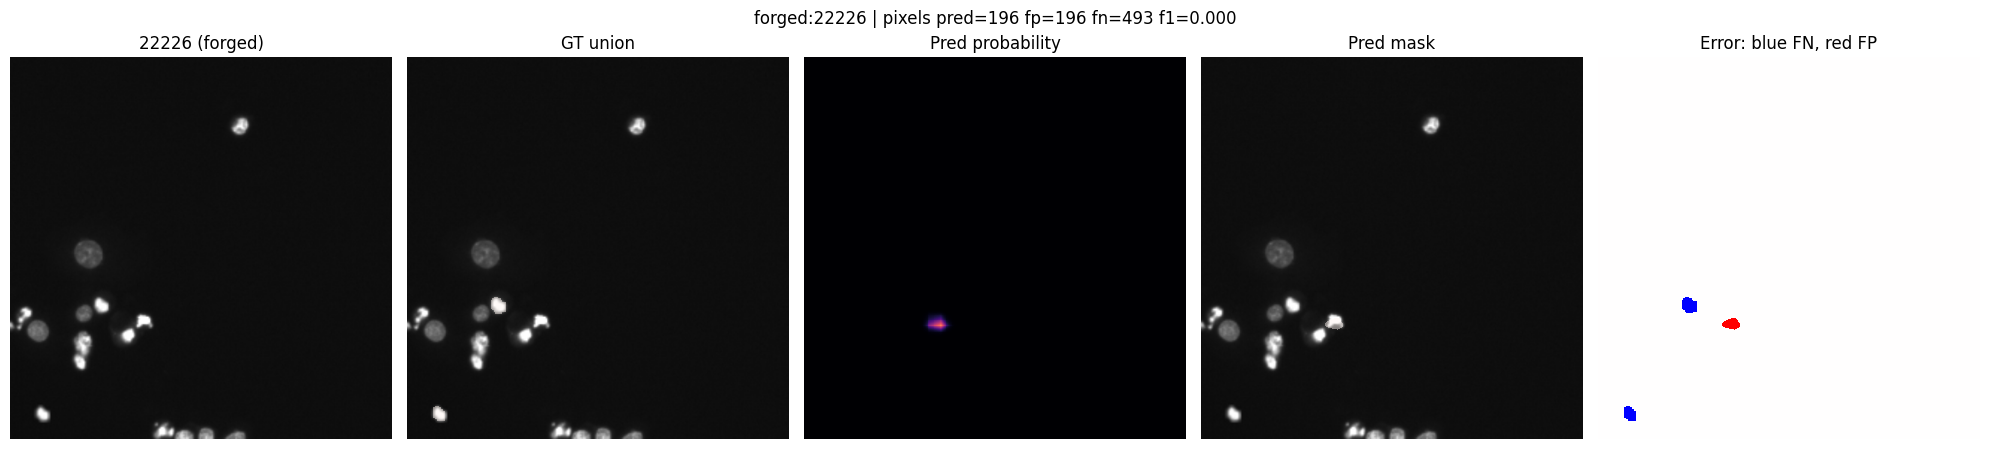

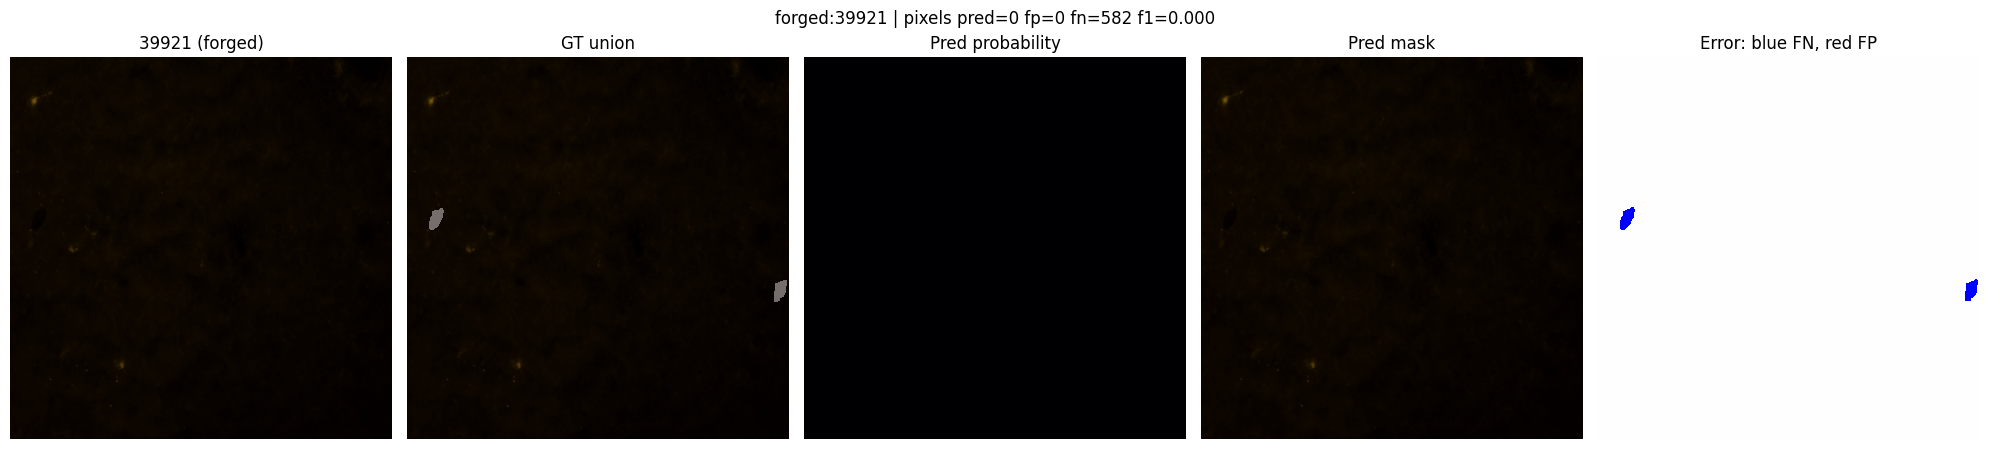

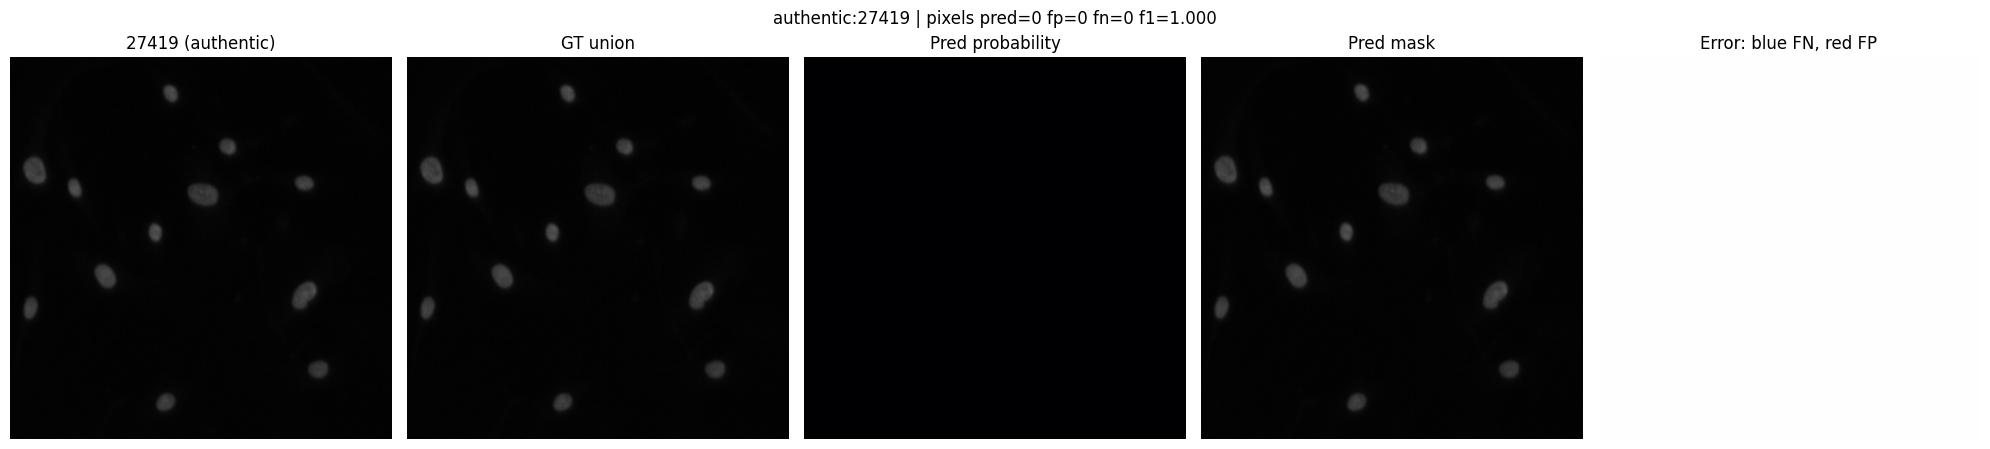

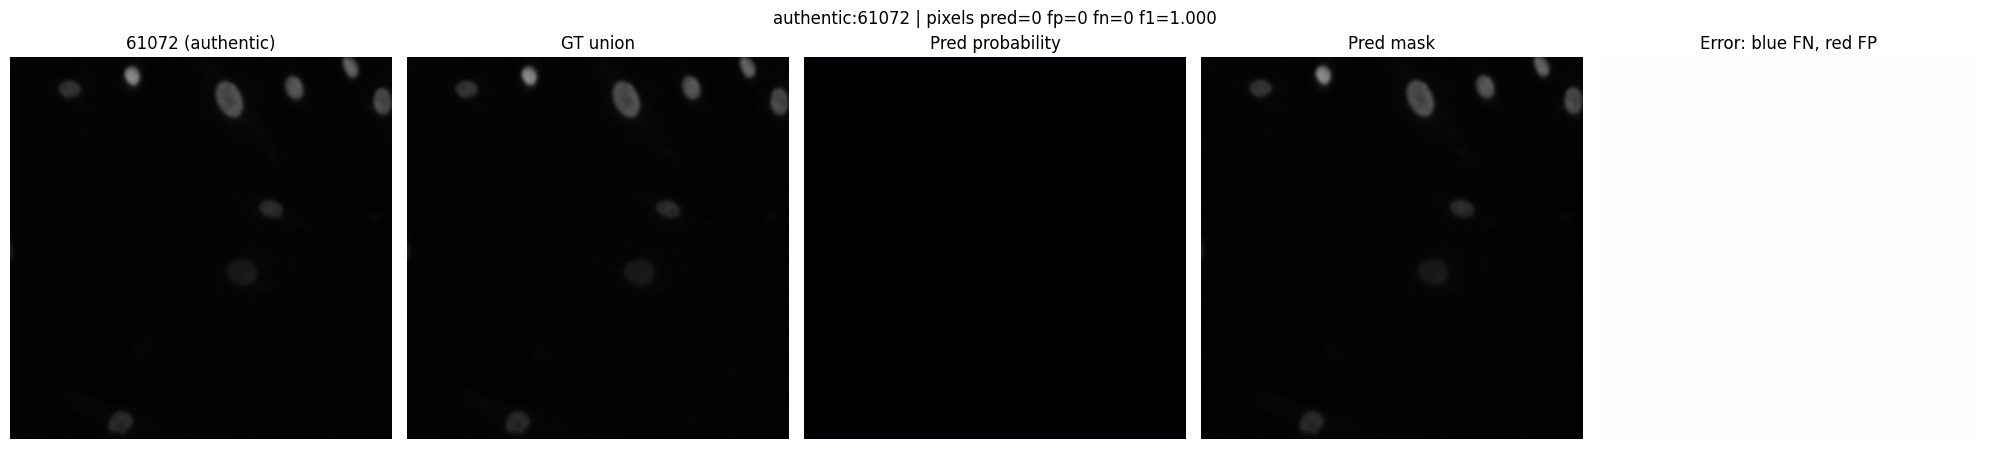

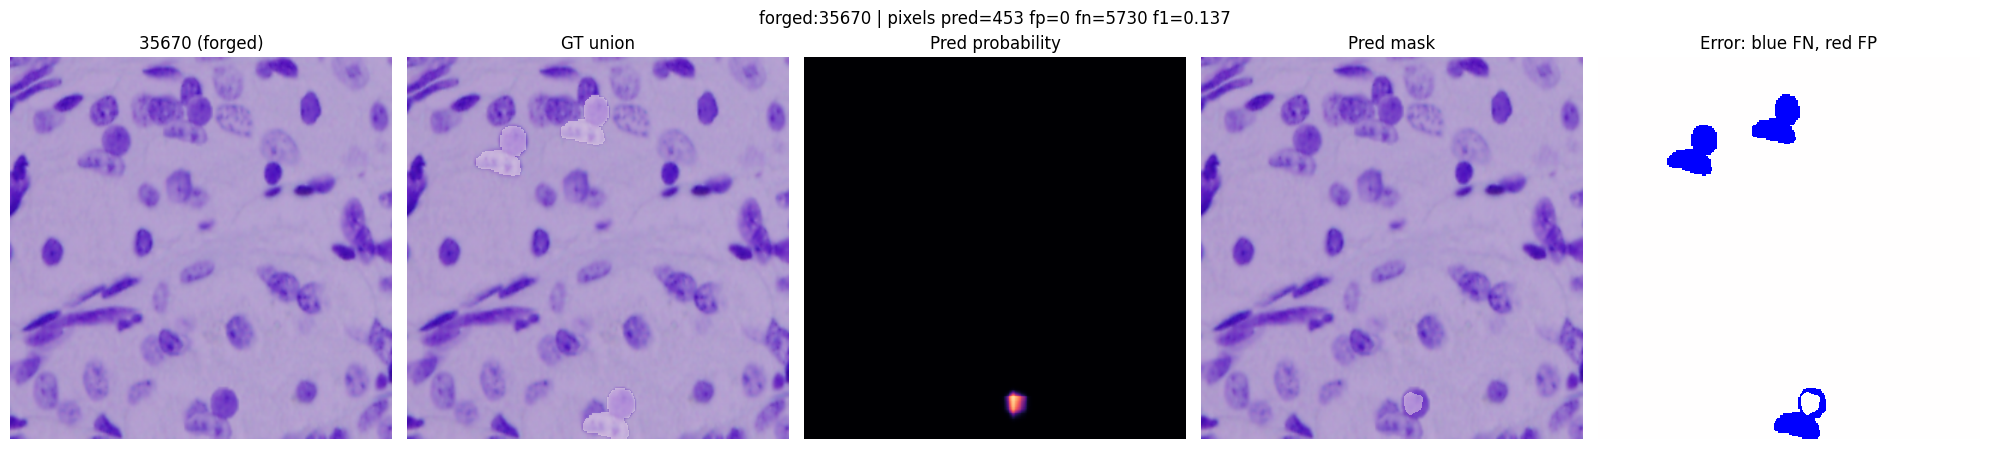

In [12]:
plotter = ForgeryDataPlotter(config.data_root)


def plot_rows(df, n=3, title=""):
    print(title)
    if len(df) == 0:
        print("No rows to plot.")
        return
    for _, row in df.head(n).iterrows():
        prediction = predictions[int(row.idx)]
        pred_bin = pred_mask_for_prediction(prediction, threshold=threshold, setting=table_setting)
        fig, axes = plotter.plot_prediction(prediction.sample, prediction.probability, pred_mask=pred_bin, threshold=threshold)
        fig.suptitle(
            f"{row.sample_id} | pixels pred={row.pred_pixels} fp={row.fp_pixels} fn={row.fn_pixels} f1={row.pixel_f1:.3f}",
            y=1.03,
        )
        plt.show()

forged_successes = diagnostic_df.query("label == 'forged' and pred_pixels > 0").sort_values(
    ["pixel_f1", "recall", "precision"], ascending=[False, False, False]
)
authentic_clean = diagnostic_df.query("label == 'authentic'").sort_values(
    ["pred_pixels", "max_prob"], ascending=[True, True]
)
random_examples = diagnostic_df.sample(n=min(6, len(diagnostic_df)), random_state=7)

plot_rows(authentic_fp, n=3, title="Authentic false positives")
plot_rows(forged_misses, n=3, title="Forged misses")
plot_rows(forged_successes, n=3, title="Forged successes")
plot_rows(authentic_clean, n=3, title="Authentic clean examples")
plot_rows(random_examples, n=6, title="Random validation examples")



## Save Diagnostics

In [13]:
output_dir = Path("einar_busternet/artifacts/results")
output_dir.mkdir(parents=True, exist_ok=True)
diagnostics_path = output_dir / "validation_diagnostics.csv"
summary_path = output_dir / "validation_diagnostics_summary.csv"
nonempty_summary_path = output_dir / "validation_diagnostics_forged_nonempty_summary.csv"
size_bucket_summary_path = output_dir / "validation_diagnostics_size_bucket_summary.csv"
diagnostic_df.to_csv(diagnostics_path, index=False)
summary.to_csv(summary_path, index=False)
forged_nonempty_summary.to_csv(nonempty_summary_path, index=False)
size_bucket_summary.to_csv(size_bucket_summary_path, index=False)
print(diagnostics_path)
print(summary_path)
print(nonempty_summary_path)
print(size_bucket_summary_path)


einar_busternet/artifacts/results/validation_diagnostics.csv
einar_busternet/artifacts/results/validation_diagnostics_summary.csv
einar_busternet/artifacts/results/validation_diagnostics_forged_nonempty_summary.csv
einar_busternet/artifacts/results/validation_diagnostics_size_bucket_summary.csv


## Cleanup GPU Memory

Run this when you are done inspecting predictions. Restarting the notebook kernel also frees everything.

In [14]:
import gc

for name in [
    "model",
    "wrapped_model",
    "val_loader",
    "predictions",
]:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(f"CUDA allocated after cleanup: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"CUDA reserved after cleanup: {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
else:
    print("CUDA not available")


CUDA allocated after cleanup: 357.9 MB
CUDA reserved after cleanup: 408.0 MB
